## Set up data and model objects


In [1]:
import pandas as pd
import numpy as np
import mudata as md
from perturbo import run_svi, run_mcmc
from perturbo._jax_module_turbo_singlegene import perturbseq_model, make_perturbseq_guide_autonormal
from perturbo._jax_utils import get_model_args, get_mdata_subset
import seaborn as sns
import matplotlib.pyplot as plt
import jax.numpy as jnp

# gene = "PRKCB"
# gene = "GATA1"
gene = "NMU"

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [2]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [3]:
def get_targeting_guides(
    mdata,
    gene,
    gene_modality=None,
    guide_modality=None,
    element_target_genes_varm_field=None,
    guide_target_elements_varm_field=None,
):
    element_target_genes_df = mdata[gene_modality].varm[element_target_genes_varm_field].loc[gene]
    # df.loc[:, df.sum() != 0]
    tested_elements = list(element_target_genes_df[element_target_genes_df > 0].index)
    print(tested_elements)
    guide_target_elements_df = mdata[guide_modality].varm[guide_target_elements_varm_field][tested_elements]
    return list(guide_target_elements_df[guide_target_elements_df.sum(axis=1) > 0].index)


guides = get_targeting_guides(
    mdata,
    gene,
    gene_modality="rna",
    guide_modality="grna",
    element_target_genes_varm_field="element_tested",
    guide_target_elements_varm_field="element_targeted",
)
guides
# guides = mdata["grna"].var_names
# guides

['NMU_TSS', 'PAICS_TSS', 'TMEM165_TSS', 'chr4:56536887-56536910']


['NMU_TSS|1',
 'NMU_TSS|2',
 'PAICS_TSS|1',
 'PAICS_TSS|2',
 'TMEM165_TSS|1',
 'TMEM165_TSS|2',
 'chr4:56536887-56536910|1',
 'chr4:56536887-56536910|2']

In [4]:
mdata["rna"].varm["element_tested"].sum(axis=1).sort_values().tail(50)

GPATCH3         15.0
TIMM17A         16.0
KDF1            16.0
RPL12P13        16.0
TRNP1           16.0
SLC9A1          16.0
WDTC1           16.0
ATP6V1C1        16.0
ZNF706          16.0
NACA4P          16.0
PIK3CG          16.0
P4HA1           17.0
CCDC71L         17.0
NUDT13          17.0
ECD             17.0
UBR5            17.0
RRM2B           17.0
NCALD           17.0
FAM149B1        17.0
DNAJC9          17.0
DNAJC9-AS1      17.0
MRPS16          17.0
RNPEP           18.0
LINC02577       18.0
PPP1R12B        18.0
UBE2T           18.0
PTPN7           18.0
ARL8A           18.0
ELF3            18.0
ELF3-AS1        18.0
SLC35F3         18.0
RPL10P4         18.0
KLF10           19.0
GNG4            19.0
AZIN1           20.0
GASAL1          21.0
TOMM20          22.0
RBM34           22.0
ARID4B          22.0
GGPS1           22.0
TBCE            22.0
B3GALNT2        22.0
LINC01132       24.0
COA6            26.0
TARBP1          26.0
IRF2BP2         26.0
COA6-AS1        26.0
U3           

In [5]:
gene

'NMU'

In [6]:
mdata_subset = get_mdata_subset(
    mdata,
    genes=[gene],
    guides=guides,
    rna_modality="rna",
    guide_modality="grna",
    guide_target_elements_varm_field="element_targeted",
)
mdata_subset

/Users/ljb80/Projects/perturbo/src/perturbo/_jax_utils.py:107: ImplicitModificationWarning: Setting element `.varm['element_targeted']` of view, initializing view as actual.
  grna_subset.varm[guide_target_elements_varm_field] = grna_by_element.loc[:, grna_by_element.sum() != 0]


MuData object with n_obs × n_vars = 47964 × 9
  2 modalities
    rna:	47964 x 1
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 8
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [7]:
# df = mdata_subset["grna"].varm["element_targeted"]
mdata_subset["grna"].varm["element_targeted"]
# mdata_subset["rna"].varm["element_tested"]
# df_subset = df.loc[:, df.sum() != 0]
# df_subset

,NMU_TSS,PAICS_TSS,TMEM165_TSS,chr4:56536887-56536910
NMU_TSS|1,1.0,0.0,0.0,0.0
NMU_TSS|2,1.0,0.0,0.0,0.0
PAICS_TSS|1,0.0,1.0,0.0,0.0
PAICS_TSS|2,0.0,1.0,0.0,0.0
TMEM165_TSS|1,0.0,0.0,1.0,0.0
TMEM165_TSS|2,0.0,0.0,1.0,0.0
chr4:56536887-56536910|1,0.0,0.0,0.0,1.0
chr4:56536887-56536910|2,0.0,0.0,0.0,1.0


In [8]:
perturbseq_guide = make_perturbseq_guide_autonormal()
model_args, model_kwargs = get_model_args(
    mdata_subset,
    rna_modality="rna",
    guide_modality="grna",
    covariates=["percent_mito", "log_total_guide_count"],
    library_size_column="library_size",
    guide_target_elements_varm_field="element_targeted",
)
for k, v in model_kwargs.items():
    print(k, v.dtype, v.shape)
for v in model_args:
    print(v.dtype, v.shape)

guide_obs bool (47964, 8)
guide_target_elements bool (8, 4)
covariates float32 (47964, 2)
size_factor float32 (47964, 1)
int16 (47964, 1)


In [9]:
# model_kwargs.update({"subsample_size": 1024})
svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model,
    perturbseq_guide,
    lr=0.01,
    n_steps=5000,
)

(47964, 8) (8, 1) (8, 4) (4, 1)
(47964, 8) (8, 1) (8, 4) (4, 1)
(47964, 8) (8, 1) (8, 4) (4, 1)
(47964, 8) (8, 1) (8, 4) (4, 1)
(47964, 8) (8, 1) (8, 4) (4, 1)
(47964, 8) (8, 1) (8, 4) (4, 1)


ValueError: Gamma distribution got invalid rate parameter.

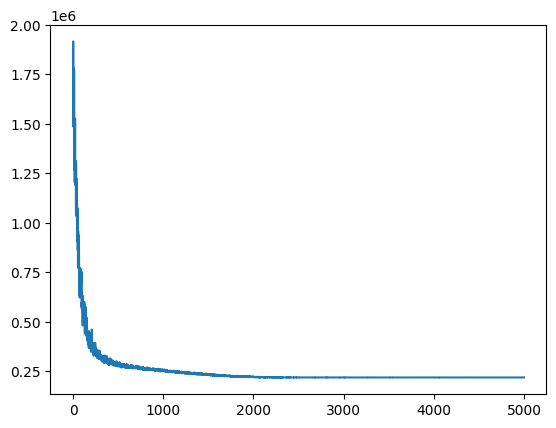

In [ ]:
plt.plot(svi_result.losses)

In [ ]:
for k,v in svi_result.params.items():
    print(k, v.shape)

covariate_weight_auto_loc (2, 1)
covariate_weight_auto_scale (2, 1)
dispersion_auto_loc (1,)
dispersion_auto_scale (1,)
log2_fold_change_auto_loc (9, 1)
log2_fold_change_auto_scale (9, 1)
mean_auto_loc (1,)
mean_auto_scale (1,)


In [ ]:
params = svi_result.params
params

{'covariate_weight_auto_loc': Array([[-0.06703947],
        [-0.03741026]], dtype=float32),
 'covariate_weight_auto_scale': Array([[0.00789984],
        [0.00837175]], dtype=float32),
 'dispersion_auto_loc': Array([0.33464274], dtype=float32),
 'dispersion_auto_scale': Array([0.04041577], dtype=float32),
 'log2_fold_change_auto_loc': Array([[-0.90628046],
        [-0.49509186],
        [-1.4354795 ],
        [-1.7095221 ],
        [-0.03245619],
        [ 0.01295143],
        [-0.05905264],
        [ 0.01058248],
        [ 0.0133883 ]], dtype=float32),
 'log2_fold_change_auto_scale': Array([[0.04027047],
        [0.05276151],
        [0.05561652],
        [0.05459084],
        [0.03858408],
        [0.03842957],
        [0.03996551],
        [0.03934258],
        [0.03603116]], dtype=float32),
 'mean_auto_loc': Array([3.6819751], dtype=float32),
 'mean_auto_scale': Array([0.02760465], dtype=float32)}

In [ ]:
perturbseq_guide.median(params)

{'mean': Array([39.724777], dtype=float32),
 'dispersion': Array([1.397441], dtype=float32),
 'covariate_weight': Array([[-0.06703947],
        [-0.03741026]], dtype=float32),
 'log2_fold_change': Array([[-0.90628046],
        [-0.49509186],
        [-1.4354795 ],
        [-1.7095221 ],
        [-0.03245619],
        [ 0.01295143],
        [-0.05905264],
        [ 0.01058248],
        [ 0.0133883 ]], dtype=float32)}

In [ ]:
unconstrained_locs = {}
for k, v in svi_result.params.items():
    param, param_type = k.split("_auto_")
    if param_type == "loc":
        unconstrained_locs[param] = v
mcmc_model_kwargs = {k: v for k, v in model_kwargs.items() if k != "subsample_size"}
mcmc_result = run_mcmc(model_args, mcmc_model_kwargs, perturbseq_model, unconstrained_locs, num_samples=1000)

sample: 100%|██████████| 2000/2000 [00:47<00:00, 42.07it/s, 7 steps of size 5.43e-01. acc. prob=0.89]


In [ ]:
for k, v in mcmc_result.get_samples().items():
    print(k, v.shape, v.mean(axis=0))

covariate_weight (1000, 2, 1) [[-0.07302696]
 [-0.03368021]]
dispersion (1000, 1) [1.4053233]
log2_fold_change (1000, 9, 1) [[-0.9163328 ]
 [-0.50101936]
 [-1.4395571 ]
 [-1.7128165 ]
 [-0.02719438]
 [ 0.01235397]
 [-0.05942788]
 [ 0.00578297]
 [ 0.01140839]]
mean (1000, 1) [39.72344]


In [ ]:
mcmc_posterior_samples = mcmc_result.get_samples()
mcmc_posterior_samples.keys()

dict_keys(['covariate_weight', 'dispersion', 'log2_fold_change', 'mean'])

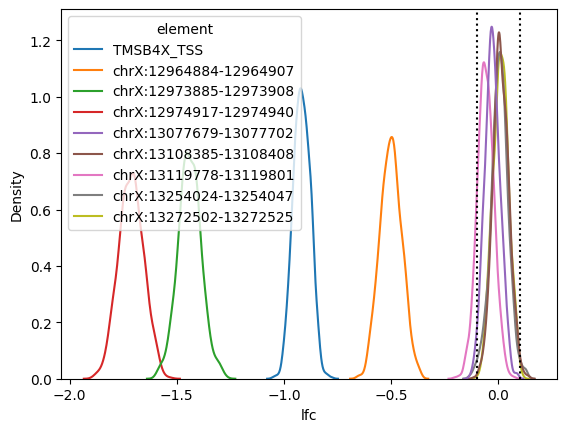

In [ ]:
elements = list(mdata_subset["rna"].varm["element_tested"].columns)
elements = list(mdata_subset["grna"].varm["element_targeted"].columns)


lfc_df = pd.DataFrame(mcmc_posterior_samples["log2_fold_change"][..., 0], columns=elements).melt(
    var_name="element", value_name="lfc"
)

g = sns.kdeplot(lfc_df, x="lfc", hue="element")
plt.axvline(-0.1, color="black", linestyle="dotted")
plt.axvline(0.1, color="black", linestyle="dotted")

# sns.move_legend(g)

(1000, 2)


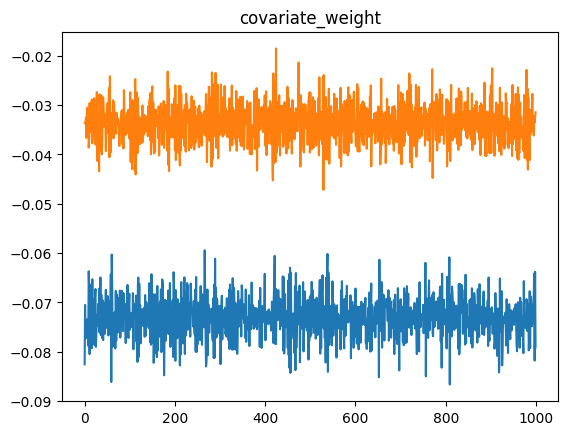

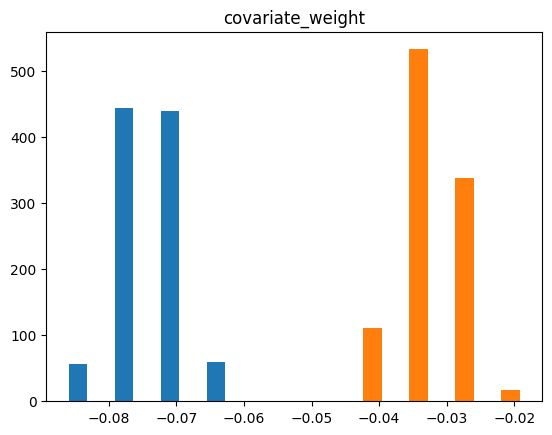

(1000,)


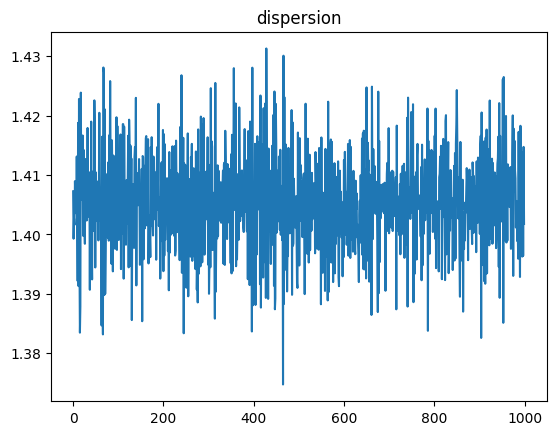

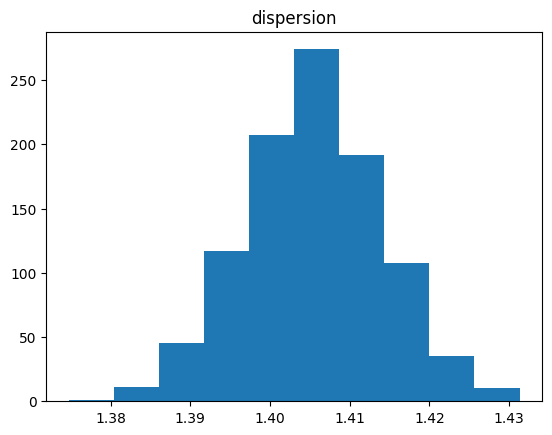

(1000, 9)


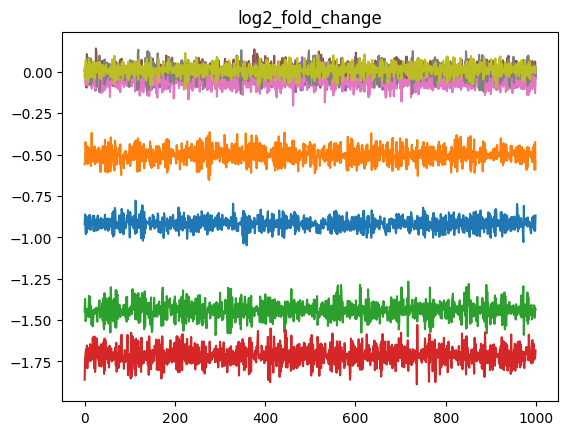

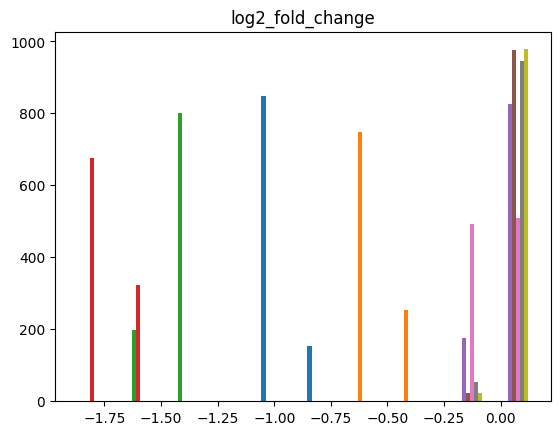

(1000,)


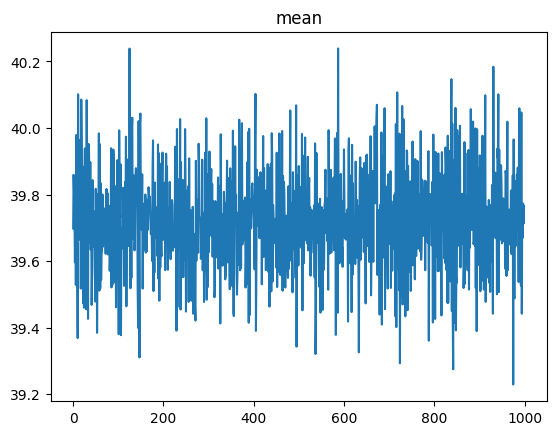

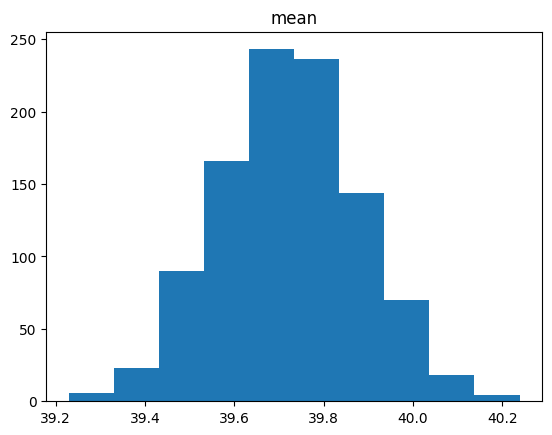

In [ ]:
for k in mcmc_posterior_samples:
    samples_k = mcmc_posterior_samples[k].squeeze()
    print(samples_k.shape)
    if len(samples_k.shape) > 2:
        continue

    plt.plot(samples_k)
    plt.title(k)
    plt.show()

    if len(samples_k.shape) == 2 and samples_k.shape[0] > 1:
        samples_k = samples_k.T

    plt.hist(samples_k)
    plt.title(k)
    plt.show()